In [2]:
!pip install torch
!pip install sentence-transformers
!pip install transformers
!pip install datasets
!pip install tensorflow
!pip install tensorflow-hub
!pip install numpy
!pip install scipy
!pip install scikit-learn
!pip install pandas
!pip install matplotlib
!pip install seaborn



In [3]:
import torch
import sentence_transformers as st
import transformers
import datasets
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import scipy
import sklearn
from sklearn.preprocessing import normalize
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from pathlib import Path

sns.set()

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Sentence-Transformers:", st.__version__)
print("Datasets:", datasets.__version__)
print("TensorFlow:", tf.__version__)


Torch: 2.10.0+cpu
Transformers: 5.0.0
Sentence-Transformers: 5.4.0
Datasets: 4.0.0
TensorFlow: 2.19.0


## Penetapan Seed agar eksperimen dapat diulang

In [4]:
SEED =  84104418

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

tf.random.set_seed(SEED)

# **Import Dataset**

## STS-B

In [5]:
stsb =  datasets.load_dataset('glue', 'stsb')
stsb_train = stsb['train'].to_pandas()
stsb_test = stsb['test'].to_pandas()
stsb_dev = stsb['validation'].to_pandas()
stsb_train.head()

#Konversi Kolom menjadi format yang sama
stsb_train_df = stsb_train.rename(columns={
    'sentence1': 'sentence_a',
    'sentence2': 'sentence_b',
    "label": "score"})

stsb_test_df = stsb_test.rename(columns={
    'sentence1': 'sentence_a',
    'sentence2': 'sentence_b',
    "label": "score"})

stsb_dev_df = stsb_dev.rename(columns={
    'sentence1': 'sentence_a',
    'sentence2': 'sentence_b',
    "label": "score"})

stsb_dev_df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

stsb/train-00000-of-00001.parquet:   0%|          | 0.00/502k [00:00<?, ?B/s]

stsb/validation-00000-of-00001.parquet:   0%|          | 0.00/151k [00:00<?, ?B/s]

stsb/test-00000-of-00001.parquet:   0%|          | 0.00/114k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]

,sentence_a,sentence_b,score,idx
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,0
1,A young child is riding a horse.,A child is riding a horse.,4.75,1
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,2
3,A woman is playing the guitar.,A man is playing guitar.,2.40,3
4,A woman is playing the flute.,A man is playing a flute.,2.75,4


## SICK

In [6]:
if not(Path("SICK.zip").exists()):
 !wget https://zenodo.org/record/2787612/files/SICK.zip?download=1 -O SICK.zip
 !unzip SICK.zip

sick = pd.read_csv('SICK.txt', sep='\t')
sick_train = sick[sick["SemEval_set"] == "TRAIN"].reset_index(drop=True)
sick_trial = sick[sick["SemEval_set"] == "TRIAL"].reset_index(drop=True)
sick_test  = sick[sick["SemEval_set"] == "TEST"].reset_index(drop=True)

def clean_sick(df):
  return df[["sentence_A", "sentence_B", "relatedness_score", "pair_ID"]]

sick_train = clean_sick(sick_train)
sick_trial = clean_sick(sick_trial)
sick_test = clean_sick(sick_test)

sick_train_df = sick_train.rename(columns={
    'sentence_A': 'sentence_a',
    'sentence_B': 'sentence_b',
    "relatedness_score": "score",
    "pair_ID": "idx"})

sick_trial_df = sick_trial.rename(columns={
    'sentence_A': 'sentence_a',
    'sentence_B': 'sentence_b',
    "relatedness_score": "score",
    "pair_ID": "idx"})

sick_test_df = sick_test.rename(columns={
    'sentence_A': 'sentence_a',
    'sentence_B': 'sentence_b',
    "relatedness_score": "score",
    "pair_ID": "idx"})

sick_test_df.head()

--2026-04-22 15:50:27--  https://zenodo.org/record/2787612/files/SICK.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.185.48.75, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/2787612/files/SICK.zip [following]
--2026-04-22 15:50:28--  https://zenodo.org/records/2787612/files/SICK.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 217584 (212K) [application/octet-stream]
Saving to: ‘SICK.zip’

SICK.zip            100%[===================>] 212.48K   242KB/s    in 0.9s    

2026-04-22 15:50:30 (242 KB/s) - ‘SICK.zip’ saved [217584/217584]

Archive:  SICK.zip
  inflating: readme.txt              
  inflating: SICK.txt                


,sentence_a,sentence_b,score,idx
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,6
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,7
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,8
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,10
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,11


# **Visualisasi Dataset**

## STS-B

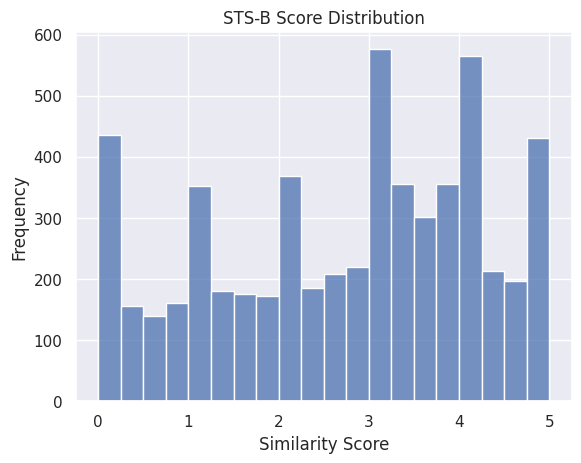

In [7]:
plt.figure()
sns.histplot(stsb_train_df["score"], bins=20)
plt.title("STS-B Score Distribution")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.show()

## SICK

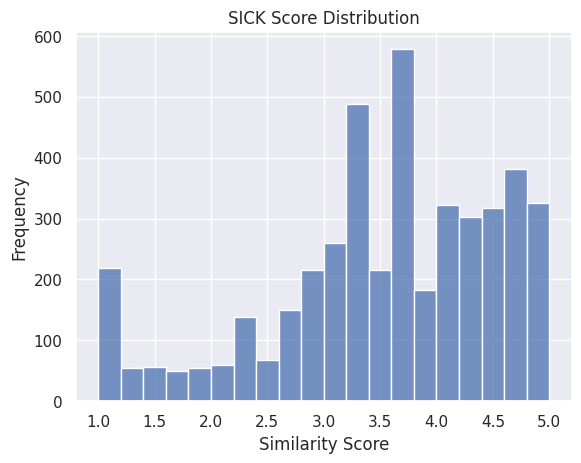

In [8]:
plt.figure()
sns.histplot(sick_train_df["score"], bins=20)
plt.title("SICK Score Distribution")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.show()

## **Panjang Kalimat**

In [9]:
stsb_train_df["len_A"] = stsb_train_df["sentence_a"].apply(lambda x: len(x.split()))
stsb_train_df["len_B"] = stsb_train_df["sentence_b"].apply(lambda x: len(x.split()))

sick_train_df["len_A"] = sick_train_df['sentence_a'].apply(lambda x: len(x.split()))
sick_train_df["len_B"] = sick_train_df['sentence_b'].apply(lambda x: len(x.split()))


## STS-B

In [10]:

print("Rata-rata panjang kalimat A: ", stsb_train_df["len_A"].mean())
print("Panjang Kalimat A Terpanjang: ", stsb_train_df["len_A"].max())
print("Panjang Kalimat A Terpendek: ", stsb_train_df["len_A"].min())
print("Rata-rata panjang kalimat B: ", stsb_train_df["len_B"].mean())
print("Panjang Kalimat B Terpanjang: ", stsb_train_df["len_B"].max())
print("Panjang Kalimat B Terpendek: ", stsb_train_df["len_B"].min())

Rata-rata panjang kalimat A:  9.950774047660463
Panjang Kalimat A Terpanjang:  56
Panjang Kalimat A Terpendek:  3
Rata-rata panjang kalimat B:  9.938945903635414
Panjang Kalimat B Terpanjang:  48
Panjang Kalimat B Terpendek:  2


Text(0, 0.5, 'Frequency')

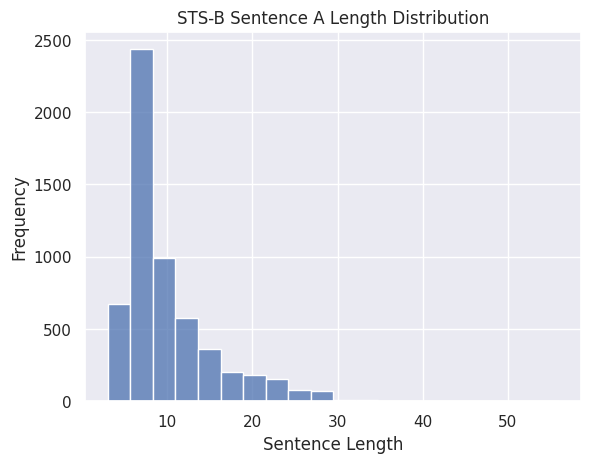

In [11]:
plt.figure()
sns.histplot(stsb_train_df['len_A'], bins=20)
plt.title("STS-B Sentence A Length Distribution")
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

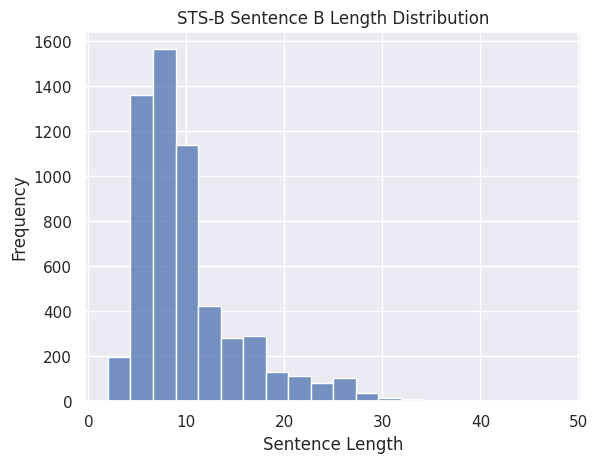

In [12]:
plt.figure()
sns.histplot(stsb_train_df['len_B'], bins=20)
plt.title("STS-B Sentence B Length Distribution")
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")

## SICK

In [13]:
print("Rata-rata panjang kalimat A: ", sick_train_df["len_A"].mean())
print("Panjang Kalimat A Terpanjang: ", sick_train_df["len_A"].max())
print("Panjang Kalimat A Terpendek: ", sick_train_df["len_A"].min())
print("Rata-rata panjang kalimat B: ", sick_train_df["len_B"].mean())
print("Panjang Kalimat B Terpanjang: ", sick_train_df["len_B"].max())
print("Panjang Kalimat B Terpendek: ", sick_train_df["len_B"].min())

Rata-rata panjang kalimat A:  9.758278891642261
Panjang Kalimat A Terpanjang:  28
Panjang Kalimat A Terpendek:  3
Rata-rata panjang kalimat B:  9.547645866186079
Panjang Kalimat B Terpanjang:  32
Panjang Kalimat B Terpendek:  3


Text(0, 0.5, 'Frequency')

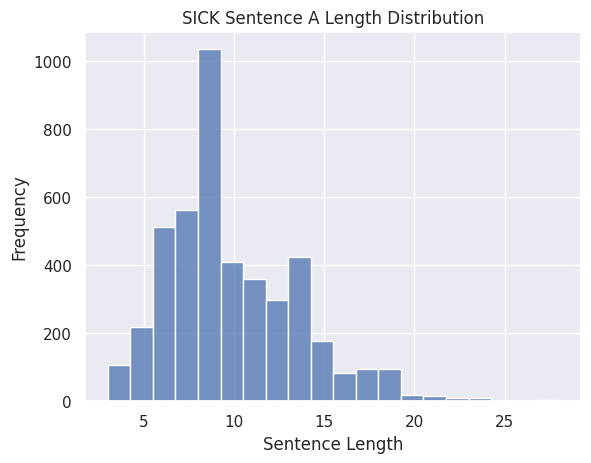

In [14]:
plt.figure()
sns.histplot(sick_train_df['len_A'], bins=20)
plt.title("SICK Sentence A Length Distribution")
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

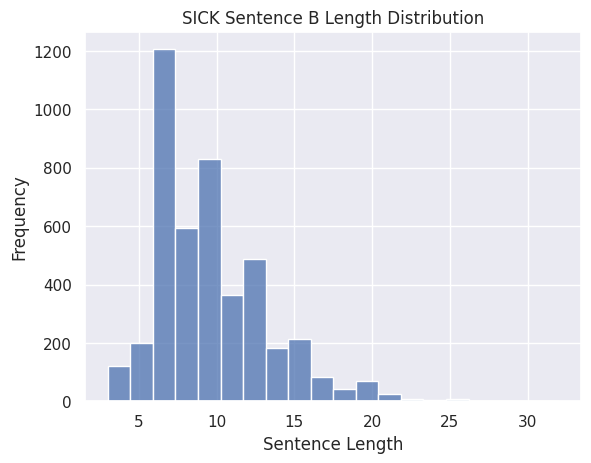

In [15]:
plt.figure()
sns.histplot(sick_train_df['len_B'], bins=20)
plt.title("SICK Sentence B Length Distribution")
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")

# **Hubungan Score dan Length**

## STS-B

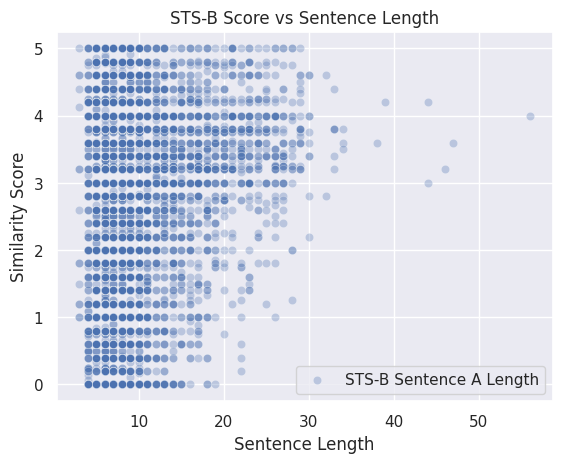

In [16]:
plt.figure()
sns.scatterplot(
    x=stsb_train_df["len_A"],
    y=stsb_train_df["score"],
    alpha=0.3,
    label="STS-B Sentence A Length"
)
plt.title("STS-B Score vs Sentence Length")
plt.xlabel("Sentence Length")
plt.ylabel("Similarity Score")
plt.show()

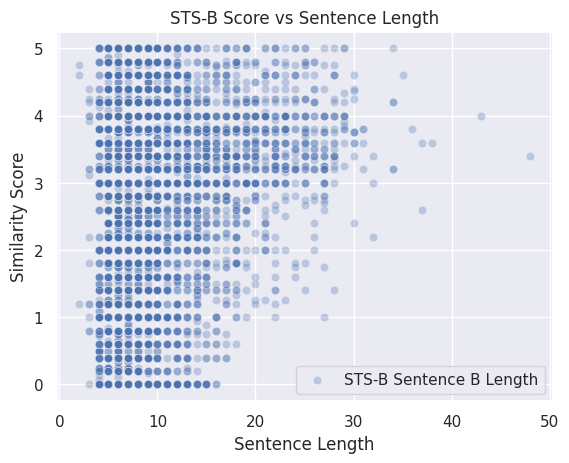

In [17]:
plt.figure()
sns.scatterplot(
    x=stsb_train_df["len_B"],
    y=stsb_train_df["score"],
    alpha=0.3,
    label="STS-B Sentence B Length"
)
plt.title("STS-B Score vs Sentence Length")
plt.xlabel("Sentence Length")
plt.ylabel("Similarity Score")
plt.show()

## SICK

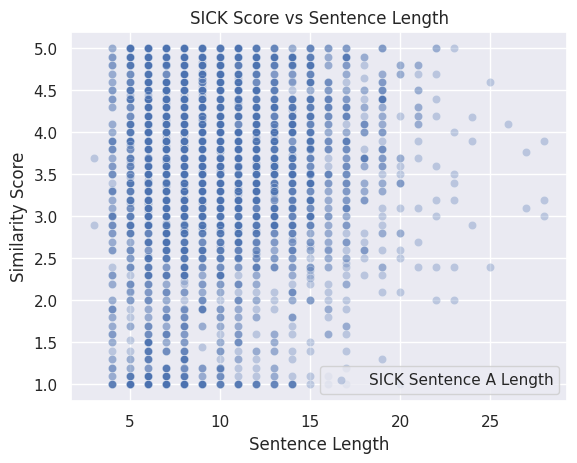

In [18]:
plt.figure()
sns.scatterplot(
    x=sick_train_df["len_A"],
    y=sick_train_df["score"],
    alpha=0.3,
    label="SICK Sentence A Length"
)
plt.title("SICK Score vs Sentence Length")
plt.xlabel("Sentence Length")
plt.ylabel("Similarity Score")
plt.show()

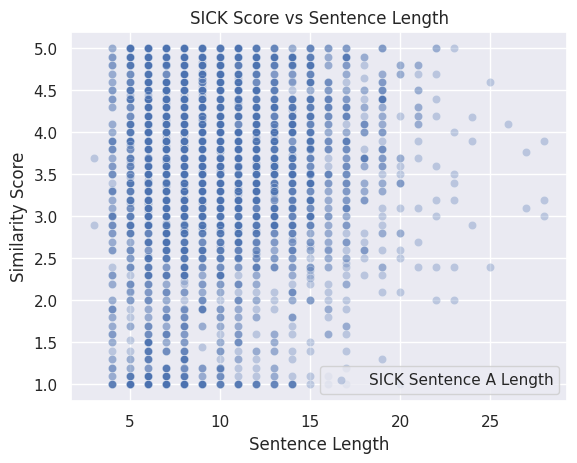

In [19]:
plt.figure()
sns.scatterplot(
    x=sick_train_df["len_A"],
    y=sick_train_df["score"],
    alpha=0.3,
    label="SICK Sentence A Length"
)
plt.title("SICK Score vs Sentence Length")
plt.xlabel("Sentence Length")
plt.ylabel("Similarity Score")
plt.show()

# **Perbandingan Dataset**

In [20]:
stsb_train_df["dataset"] = "STS-B"
sick_train_df["dataset"] = "SICK"

stsb_train_df["score_norm"] = stsb_train_df["score"] / 5.0
sick_train_df["score_norm"] = (sick_train_df["score"] - 1) / 4

combined = pd.concat([
    stsb_train_df[["score_norm", "dataset"]],
    sick_train_df[["score_norm", "dataset"]]], ignore_index=True)
combined

,score_norm,dataset
0,1.000,STS-B
1,0.760,STS-B
2,0.760,STS-B
3,0.520,STS-B
4,0.850,STS-B
...,...,...
10183,0.025,SICK
10184,0.000,SICK
10185,0.000,SICK
10186,0.050,SICK


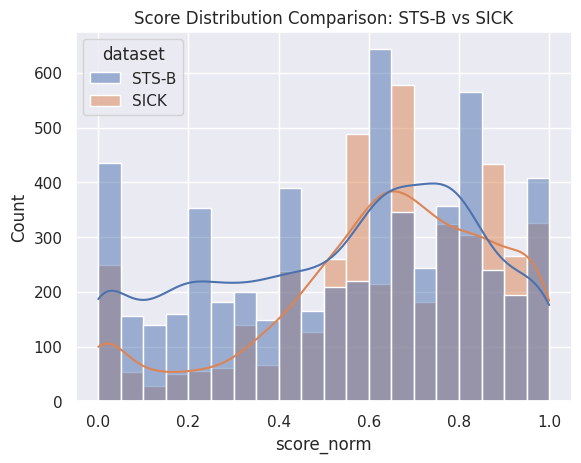

In [21]:
plt.figure()
sns.histplot(data=combined, x="score_norm", hue="dataset", bins=20, kde=True)
plt.title("Score Distribution Comparison: STS-B vs SICK")
plt.show()

# **Load Embedding Model**

In [22]:
def load_models():
  models = {}

  models["sbert"] = st.SentenceTransformer("all-mpnet-base-v2")
  models["simcse"] = st.SentenceTransformer("princeton-nlp/unsup-simcse-bert-base-uncased")
  models["labse"] = st.SentenceTransformer("sentence-transformers/LaBSE")
  models["use"] = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

  return models

models = load_models()

def embed_sentences(model, sentences, model_name):
  if model_name == "use":
    embeddings = model(sentences).numpy()
  else:
    embeddings = model.encode(
        sentences,
        convert_to_numpy=True,
        batch_size=32,
        show_progress_bar=True
        )

  return embeddings

def embed_pairs(model, s1, s2, model_name):
  emb1 = embed_sentences(model, s1, model_name)
  emb2 = embed_sentences(model, s2, model_name)
  return emb1, emb2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

In [23]:
sentences = [
    "A man is playing guitar",
    "A person is playing music"
]

emb_sbert = embed_sentences(models["sbert"], sentences, "sbert")
emb_simcse = embed_sentences(models["simcse"], sentences, "simcse")
emb_labse = embed_sentences(models["labse"], sentences, "labse")
emb_use = embed_sentences(models["use"], sentences, "use")

print("SBERT:", emb_sbert.shape)
print("SimCSE:", emb_simcse.shape)
print("LaBSE:", emb_labse.shape)
print("USE:", emb_use.shape)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

SBERT: (2, 768)
SimCSE: (2, 768)
LaBSE: (2, 768)
USE: (2, 512)


# Embedding data menggunakan model

In [24]:
stsb_s1 = stsb_dev_df["sentence_a"].tolist()
stsb_s2 = stsb_dev_df["sentence_b"].tolist()
stsb_score = stsb_dev_df["score"].tolist()

sick_s1 = sick_test_df["sentence_a"].tolist()
sick_s2 = sick_test_df["sentence_b"].tolist()
sick_score = sick_test_df["score"].tolist()

emb_stsb_sbert = {}
emb_sick_sbert = {}
emb_stsb_sbert["s1"], emb_stsb_sbert["s2"] = embed_pairs(models["sbert"], stsb_s1, stsb_s2, "sbert")
emb_sick_sbert["s1"], emb_sick_sbert["s2"] = embed_pairs(models["sbert"], sick_s1, sick_s2, "sbert")

emb_stsb_simcse = {}
emb_sick_simcse = {}
emb_stsb_simcse["s1"], emb_stsb_simcse["s2"] = embed_pairs(models["simcse"], stsb_s1, stsb_s2, "simcse")
emb_sick_simcse["s1"], emb_sick_simcse["s2"] = embed_pairs(models["simcse"], sick_s1, sick_s2, "simcse")

emb_stsb_labse = {}
emb_sick_labse = {}
emb_stsb_labse["s1"], emb_stsb_labse["s2"] = embed_pairs(models['labse'], stsb_s1, stsb_s2, "labse")
emb_sick_labse["s1"], emb_sick_labse["s2"] = embed_pairs(models['labse'], sick_s1, sick_s2, "labse")

emb_stsb_use = {}
emb_sick_use = {}
emb_stsb_use["s1"], emb_stsb_use["s2"] = embed_pairs(models['use'], stsb_s1, stsb_s2, "use")
emb_sick_use["s1"], emb_sick_use["s2"] = embed_pairs(models['use'], sick_s1, sick_s2, "use")


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Batches:   0%|          | 0/154 [00:00<?, ?it/s]

Batches:   0%|          | 0/154 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/154 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Batches:   0%|          | 0/154 [00:00<?, ?it/s]

Batches:   0%|          | 0/154 [00:00<?, ?it/s]

In [25]:

def cosine_similarity_batch(emb1, emb2):
  numerator = np.sum(emb1 * emb2, axis=1)
  dominator = np.linalg.norm(emb1, axis=1) * np.linalg.norm(emb2, axis=1)

  similarity = numerator / (dominator + 1e-8)
  # similarity = numerator / dominator
  return similarity

def evaluate_simlarity(pred_scores, gold_scores):
  pearson = scipy.stats.pearsonr(pred_scores, gold_scores)[0]
  spearman = scipy.stats.spearmanr(pred_scores, gold_scores)[0]

  return {
      "pearson": pearson,
      "spearman": spearman
  }

def run_evaluation(emb1, emb2, gold_scores):
  pred_scores = cosine_similarity_batch(emb1, emb2)
  res = evaluate_simlarity(pred_scores, gold_scores)
  return pred_scores, res

def scale_cosine_to_0_5(cosine_scores):
  return (cosine_scores + 1) * 2.5

def scale_cosine_to_1_5(cosine_scores):
  return (cosine_scores + 1) * 2 + 1

result_stsb = pd.DataFrame({
    "sentence_a":stsb_s1,
    "sentence_b":stsb_s2,
    "gold_scored":stsb_score})

result_sick = pd.DataFrame({
    "sentence_a":sick_s1,
    "sentence_b":sick_s2,
    "gold_scored":sick_score})


## SBERT

In [26]:
result_stsb_sbert = result_stsb.copy()
temp, eval_res_stsb_sbert = run_evaluation(emb_stsb_sbert["s1"], emb_stsb_sbert["s2"], stsb_score)
result_stsb_sbert["pred_scores_scaled"] = scale_cosine_to_0_5(temp)
result_stsb_sbert["pred_scores_raw"] = temp
print(eval_res_stsb_sbert)

result_stsb_sbert

{'pearson': np.float64(0.8806252622289203), 'spearman': np.float64(0.8810927674106779)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.991763,0.996705
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.877413,0.950965
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.635848,0.854339
3,A woman is playing the guitar.,A man is playing guitar.,2.40,3.987226,0.594890
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.339110,0.735644
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.501303,0.800521
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.273325,0.309330
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.684501,0.473800
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.094093,0.237637


In [27]:
result_sick_sbert = result_sick.copy()
temp, eval_res_sick_sbert = run_evaluation(emb_sick_sbert["s1"], emb_sick_sbert["s2"], sick_score)
result_sick_sbert["pred_scores_scaled"] = scale_cosine_to_1_5(temp)
result_sick_sbert["pred_scores_raw"] = temp
print(eval_res_sick_sbert)

result_sick_sbert

{'pearson': np.float64(0.838836169716854), 'spearman': np.float64(0.8049153593251246)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,3.359155,0.179577
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.404498,0.702249
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,3.507639,0.253820
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.900795,0.950397
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.415457,0.707729
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.383707,0.191853
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,2.949362,-0.025319
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.184610,0.092305
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,2.937209,-0.031395


## SIMCSE

In [28]:
result_stsb_simcse = result_stsb.copy()
temp, eval_res_stsb_simcse = run_evaluation(emb_stsb_simcse["s1"], emb_stsb_simcse["s2"], stsb_score)
result_stsb_simcse["pred_scores_scaled"] = scale_cosine_to_0_5(temp)
result_stsb_simcse["pred_scores_raw"] = temp
print(eval_res_stsb_simcse)

result_stsb_simcse

{'pearson': np.float64(0.8396503414866399), 'spearman': np.float64(0.8406170018269499)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.977728,0.991091
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.949574,0.979830
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.946491,0.978597
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.866865,0.946746
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.875807,0.950323
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.700155,0.880062
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.589599,0.435839
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.772618,0.509047
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.708818,0.483527


In [29]:
result_sick_simcse = result_sick.copy()
temp, eval_res_sick_simcse = run_evaluation(emb_sick_simcse["s1"], emb_sick_simcse["s2"], sick_score)
result_sick_simcse["pred_scores_scaled"] = scale_cosine_to_1_5(temp)
result_sick_simcse["pred_scores_raw"] = temp
print(eval_res_sick_simcse)

result_sick_simcse

{'pearson': np.float64(0.7911546074107879), 'spearman': np.float64(0.7037436837748254)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,4.472113,0.736057
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.661169,0.830585
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.577524,0.788762
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.933601,0.966801
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.905797,0.952898
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.939353,0.469676
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.515083,0.257541
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.869255,0.434627
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.787542,0.393771


## LABSE

In [30]:
result_stsb_labse = result_stsb.copy()
temp, eval_res_stsb_labse = run_evaluation(emb_stsb_labse["s1"], emb_stsb_labse["s2"], stsb_score)
result_stsb_labse["pred_scores_scaled"] = scale_cosine_to_0_5(temp)
result_stsb_labse["pred_scores_raw"] = temp
print(eval_res_stsb_labse)

result_stsb_labse

{'pearson': np.float64(0.7293843886948486), 'spearman': np.float64(0.7412647108429445)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.943940,0.977576
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.808732,0.923493
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.906443,0.962577
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.580748,0.832299
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.482345,0.792938
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.252686,0.701074
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.321286,0.328514
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.750485,0.500194
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.562546,0.425018


In [31]:
result_sick_labse = result_sick.copy()
temp, eval_res_sick_labse = run_evaluation(emb_sick_labse["s1"], emb_sick_labse["s2"], sick_score)
result_sick_labse["pred_scores_scaled"] = scale_cosine_to_1_5(temp)
result_sick_labse["pred_scores_raw"] = temp
print(eval_res_sick_labse)

result_sick_labse

{'pearson': np.float64(0.7354292896495569), 'spearman': np.float64(0.6975704989041174)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,4.034352,0.517176
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.410022,0.705011
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.273774,0.636887
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.930348,0.965174
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.789928,0.894964
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.923335,0.461668
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.546103,0.273051
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.804137,0.402069
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.276269,0.138135


## USE

In [32]:
result_stsb_use = result_stsb.copy()
temp, eval_res_stsb_use = run_evaluation(emb_stsb_use["s1"], emb_stsb_use["s2"], stsb_score)
result_stsb_use["pred_scores_scaled"] = scale_cosine_to_0_5(temp)
result_stsb_use["pred_scores_raw"] = temp
print(eval_res_stsb_use)

result_stsb_use

{'pearson': np.float64(0.8077681763666837), 'spearman': np.float64(0.808916562519709)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.940185,0.976074
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.911468,0.964587
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.840944,0.936378
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.593768,0.837507
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.631582,0.852633
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.512529,0.805011
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.087608,0.235043
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.420847,0.368339
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.440134,0.376054


In [33]:
result_sick_use = result_sick.copy()
temp, eval_res_sick_use = run_evaluation(emb_sick_use["s1"], emb_sick_use["s2"], sick_score)
result_sick_use["pred_scores_scaled"] = scale_cosine_to_1_5(temp)
result_sick_use["pred_scores_raw"] = temp
print(eval_res_sick_use)

result_sick_use

{'pearson': np.float64(0.7712873943459142), 'spearman': np.float64(0.693154998788687)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,3.819128,0.409564
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.003989,0.501994
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,3.796322,0.398161
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.877954,0.938977
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.793663,0.896832
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.494336,0.247168
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.182889,0.091445
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.295244,0.147622
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.340008,0.170004


# **Text Embedding Fusion**

In [34]:
def fuse_concat(embeddings_list):
  return np.concatenate(embeddings_list, axis=1)

def fuse_concat_norm(embeddings_list):
  norm_embs = [normalize(e) for e in embeddings_list]
  return np.concatenate(norm_embs, axis=1)

def run_fusion_experiment(model_combination):
  emb_stsbs1_list = []
  emb_stsbs2_list = []
  emb_sicks1_list = []
  emb_sicks2_list = []
  for model in model_combination:
    print(model)
    if model == "sbert":
      emb_stsbs1_list.append(emb_stsb_sbert["s1"])
      emb_stsbs2_list.append(emb_stsb_sbert["s2"])
      emb_sicks1_list.append(emb_sick_sbert["s1"])
      emb_sicks2_list.append(emb_sick_sbert["s2"])
    elif model == "simcse":
      emb_stsbs1_list.append(emb_stsb_simcse["s1"])
      emb_stsbs2_list.append(emb_stsb_simcse["s2"])
      emb_sicks1_list.append(emb_sick_simcse["s1"])
      emb_sicks2_list.append(emb_sick_simcse["s2"])
    elif model == "labse":
      emb_stsbs1_list.append(emb_stsb_labse["s1"])
      emb_stsbs2_list.append(emb_stsb_labse["s2"])
      emb_sicks1_list.append(emb_sick_labse["s1"])
      emb_sicks2_list.append(emb_sick_labse["s2"])
    elif model == "use":
      emb_stsbs1_list.append(emb_stsb_use["s1"])
      emb_stsbs2_list.append(emb_stsb_use["s2"])
      emb_sicks1_list.append(emb_sick_use["s1"])
      emb_sicks2_list.append(emb_sick_use["s2"])

  result_stsb_fusion = result_stsb.copy()
  result_stsb_fusion_norm = result_stsb.copy()
  result_sick_fusion = result_sick.copy()
  result_sick_fusion_norm = result_sick.copy()

  emb_stsbs1 = fuse_concat(emb_stsbs1_list)
  emb_stsbs2 = fuse_concat(emb_stsbs2_list)
  emb_stsbs1_norm = fuse_concat_norm(emb_stsbs1_list)
  emb_stsbs2_norm = fuse_concat_norm(emb_stsbs2_list)

  emb_sicks1 = fuse_concat(emb_sicks1_list)
  emb_sicks2 = fuse_concat(emb_sicks2_list)
  emb_sicks1_norm = fuse_concat_norm(emb_sicks1_list)
  emb_sicks2_norm = fuse_concat_norm(emb_sicks2_list)

  temp, eval_res_stsb_fusion = run_evaluation(emb_stsbs1, emb_stsbs2, stsb_score)
  result_stsb_fusion["pred_scores_scaled"] = scale_cosine_to_0_5(temp)
  result_stsb_fusion["pred_scores_raw"] = temp

  temp, eval_res_stsb_fusion_norm = run_evaluation(emb_stsbs1_norm, emb_stsbs2_norm, stsb_score)
  result_stsb_fusion_norm["pred_scores_scaled"] = scale_cosine_to_0_5(temp)
  result_stsb_fusion_norm["pred_scores_raw"] = temp

  temp, eval_res_sick_fusion = run_evaluation(emb_sicks1, emb_sicks2, sick_score)
  result_sick_fusion["pred_scores_scaled"] = scale_cosine_to_1_5(temp)
  result_sick_fusion["pred_scores_raw"] = temp

  temp, eval_res_sick_fusion_norm = run_evaluation(emb_sicks1_norm, emb_sicks2_norm, sick_score)
  result_sick_fusion_norm["pred_scores_scaled"] = scale_cosine_to_1_5(temp)
  result_sick_fusion_norm["pred_scores_raw"] = temp

  return {
      "eval_stsb" : eval_res_stsb_fusion,
      "result_stsb" : result_stsb_fusion,
      "eval_stsb_norm" : eval_res_stsb_fusion_norm,
      "result_stsb_norm" : result_stsb_fusion_norm,
      "eval_sick" : eval_res_sick_fusion,
      "result_sick" : result_sick_fusion,
      "eval_sick_norm" : eval_res_sick_fusion_norm,
      "result_sick_norm" : result_sick_fusion_norm
  }


## SBERT + SIMCSE

In [35]:
combination = ["sbert", "simcse"]

result_sbert_simcse = run_fusion_experiment(combination)

print("STSB")
print(result_sbert_simcse["eval_stsb"])
display(result_sbert_simcse["result_stsb"])

print("\nSTSB Normalized")
print(result_sbert_simcse["eval_stsb_norm"])
display(result_sbert_simcse["result_stsb_norm"])

print("\nSICK")
print(result_sbert_simcse["eval_sick"])
display(result_sbert_simcse["result_sick"])

print("\nSICK Normalized")
print(result_sbert_simcse["eval_sick_norm"])
display(result_sbert_simcse["result_sick_norm"])

sbert
simcse
STSB
{'pearson': np.float64(0.840996806137001), 'spearman': np.float64(0.8419821351900691)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.977807,0.991123
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.949173,0.979669
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.944604,0.977842
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.862040,0.944816
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.872854,0.949142
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.699043,0.879617
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.587691,0.435077
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.772056,0.508822
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.705690,0.482276



STSB Normalized
{'pearson': np.float64(0.8938408359826588), 'spearman': np.float64(0.8947141807134434)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.984746,0.993898
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.913494,0.965398
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.791170,0.916468
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.427045,0.770818
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.607459,0.842983
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.600729,0.840292
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.431462,0.372585
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.728559,0.491424
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.401456,0.360582



SICK
{'pearson': np.float64(0.7926532310823882), 'spearman': np.float64(0.7062322785378604)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,4.465741,0.732871
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.659650,0.829825
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.571075,0.785538
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.933416,0.966708
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.903111,0.951556
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.936156,0.468078
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.511961,0.255981
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.865222,0.432611
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.782599,0.391299



SICK Normalized
{'pearson': np.float64(0.8535418986790263), 'spearman': np.float64(0.8000290785793801)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,3.915634,0.457817
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.532833,0.766417
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.042582,0.521291
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.917198,0.958599
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.660627,0.830314
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.661530,0.330765
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.232223,0.116111
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.526932,0.263466
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.362375,0.181188


## SBERT + LABSE

In [36]:
combination = ["sbert", "labse"]

result_sbert_labse = run_fusion_experiment(combination)

print("STSB")
print(result_sbert_labse["eval_stsb"])
display(result_sbert_labse["result_stsb"])

print("\nSTSB Normalized")
print(result_sbert_labse["eval_stsb_norm"])
display(result_sbert_labse["result_stsb_norm"])

print("\nSICK")
print(result_sbert_labse["eval_sick"])
display(result_sbert_labse["result_sick"])

print("\nSICK Normalized")
print(result_sbert_labse["eval_sick_norm"])
display(result_sbert_labse["result_sick_norm"])

sbert
labse
STSB
{'pearson': np.float64(0.8693025606581867), 'spearman': np.float64(0.8696047424722684)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.967852,0.987141
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.843072,0.937229
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.771145,0.908458
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.283987,0.713595
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.410728,0.764291
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.376994,0.750798
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.297306,0.318922
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.717493,0.486997
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.328320,0.331328



STSB Normalized
{'pearson': np.float64(0.8693025588853353), 'spearman': np.float64(0.8696047424722684)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.967852,0.987141
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.843073,0.937229
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.771145,0.908458
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.283987,0.713595
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.410728,0.764291
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.376994,0.750798
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.297306,0.318922
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.717493,0.486997
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.328320,0.331328



SICK
{'pearson': np.float64(0.8322192265100606), 'spearman': np.float64(0.7940175810558748)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,3.696754,0.348377
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.407260,0.703630
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,3.890707,0.445353
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.915572,0.957786
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.602693,0.801346
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.653521,0.326761
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.247733,0.123866
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.494374,0.247187
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.106739,0.053370



SICK Normalized
{'pearson': np.float64(0.8322192282251388), 'spearman': np.float64(0.7940175755494234)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,3.696754,0.348377
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.407260,0.703630
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,3.890707,0.445353
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.915571,0.957786
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.602693,0.801346
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.653521,0.326761
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.247733,0.123866
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.494374,0.247187
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.106739,0.053370


## SBERT + USE

In [37]:
combination = ["sbert", "use"]

result_sbert_use = run_fusion_experiment(combination)

print("STSB")
print(result_sbert_use["eval_stsb"])
display(result_sbert_use["result_stsb"])

print("\nSTSB Normalized")
print(result_sbert_use["eval_stsb_norm"])
display(result_sbert_use["result_stsb_norm"])

print("\nSICK")
print(result_sbert_use["eval_sick"])
display(result_sbert_use["result_sick"])

print("\nSICK Normalized")
print(result_sbert_use["eval_sick_norm"])
display(result_sbert_use["result_sick_norm"])

sbert
use
STSB
{'pearson': np.float64(0.8798985793266316), 'spearman': np.float64(0.8780751789227893)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.965974,0.986390
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.894440,0.957776
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.738396,0.895358
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.290496,0.716199
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.485346,0.794138
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.506916,0.802766
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.180467,0.272187
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.552674,0.421070
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.267114,0.306845



STSB Normalized
{'pearson': np.float64(0.8798985834807508), 'spearman': np.float64(0.8780751789227893)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.965974,0.986390
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.894440,0.957776
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.738396,0.895358
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.290497,0.716199
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.485347,0.794139
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.506916,0.802766
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.180467,0.272187
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.552674,0.421070
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.267114,0.306845



SICK
{'pearson': np.float64(0.8410109522415947), 'spearman': np.float64(0.7901830390507262)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,3.589141,0.294571
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.204243,0.602122
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,3.651981,0.325990
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.889374,0.944687
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.604560,0.802280
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.439021,0.219511
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.066126,0.033063
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.239927,0.119963
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.138609,0.069304



SICK Normalized
{'pearson': np.float64(0.8410109492982945), 'spearman': np.float64(0.7901828538061169)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,3.589141,0.294571
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.204243,0.602122
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,3.651981,0.325990
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.889375,0.944687
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.604560,0.802280
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.439021,0.219511
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.066126,0.033063
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.239927,0.119963
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.138609,0.069304


## SIMCSE + LABSE

In [38]:
combination = ["simcse", "labse"]

result_simcse_labse = run_fusion_experiment(combination)

print("STSB")
print(result_simcse_labse["eval_stsb"])
display(result_simcse_labse["result_stsb"])

print("\nSTSB Normalized")
print(result_simcse_labse["eval_stsb_norm"])
display(result_simcse_labse["result_stsb_norm"])

print("\nSICK")
print(result_simcse_labse["eval_sick"])
display(result_simcse_labse["result_sick"])

print("\nSICK Normalized")
print(result_simcse_labse["eval_sick_norm"])
display(result_simcse_labse["result_sick_norm"])

simcse
labse
STSB
{'pearson': np.float64(0.8398688438335564), 'spearman': np.float64(0.8408533649793903)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.977533,0.991013
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.948792,0.979517
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.946242,0.978497
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.865294,0.946118
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.873641,0.949457
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.697679,0.879071
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.587980,0.435192
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.772452,0.508981
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.708068,0.483227



STSB Normalized
{'pearson': np.float64(0.8139692885060961), 'spearman': np.float64(0.8190035812173474)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.960834,0.984334
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.879153,0.951661
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.926467,0.970587
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.723806,0.889523
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.679076,0.871630
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.476420,0.790568
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.455442,0.382177
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.761551,0.504621
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.635682,0.454273



SICK
{'pearson': np.float64(0.7915891834459807), 'spearman': np.float64(0.7044190609800255)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,4.469605,0.734803
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.659683,0.829841
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.575693,0.787847
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.933581,0.966791
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.905162,0.952581
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.939260,0.469630
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.515252,0.257626
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.868845,0.434422
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.784567,0.392284



SICK Normalized
{'pearson': np.float64(0.7957828623048422), 'spearman': np.float64(0.7298427611458451)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,4.253233,0.626616
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.535596,0.767798
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.425649,0.712825
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.931975,0.965987
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.847862,0.923931
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.931344,0.465672
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.530593,0.265296
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.836696,0.418348
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.531906,0.265953


## SIMCE + USE

In [39]:
combination = ["simcse", "use"]

result_simcse_use = run_fusion_experiment(combination)

print("STSB")
print(result_simcse_use["eval_stsb"])
display(result_simcse_use["result_stsb"])

print("\nSTSB Normalized")
print(result_simcse_use["eval_stsb_norm"])
display(result_simcse_use["result_stsb_norm"])

print("\nSICK")
print(result_simcse_use["eval_sick"])
display(result_simcse_use["result_sick"])

print("\nSICK Normalized")
print(result_simcse_use["eval_sick_norm"])
display(result_simcse_use["result_sick_norm"])

simcse
use
STSB
{'pearson': np.float64(0.8400537219459492), 'spearman': np.float64(0.8410600715277348)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.977512,0.991005
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.949363,0.979745
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.945846,0.978339
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.865366,0.946146
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.874461,0.949785
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.699105,0.879642
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.586572,0.434629
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.770476,0.508190
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.707447,0.482979



STSB Normalized
{'pearson': np.float64(0.8441204612152484), 'spearman': np.float64(0.8442201466622731)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.958957,0.983583
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.930521,0.972208
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.893718,0.957487
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.730316,0.892126
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.753695,0.901478
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.606342,0.842537
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.338603,0.335441
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.596732,0.438693
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.574476,0.429790



SICK
{'pearson': np.float64(0.7914913483643191), 'spearman': np.float64(0.7040137163955499)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,4.468374,0.734187
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.657281,0.828641
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.572815,0.786408
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.933289,0.966644
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.905183,0.952591
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.936792,0.468396
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.513249,0.256625
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.865869,0.432934
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.784937,0.392469



SICK Normalized
{'pearson': np.float64(0.7968614599126264), 'spearman': np.float64(0.7090979657420936)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,4.145620,0.572810
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.332579,0.666290
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.186924,0.593462
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.905778,0.952889
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.849730,0.924865
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.716844,0.358422
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.348986,0.174493
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.582249,0.291125
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.563775,0.281887


## LABSE + USE

In [40]:
combination = ["labse", "use"]

result_labse_use = run_fusion_experiment(combination)

print("STSB")
print(result_labse_use["eval_stsb"])
display(result_labse_use["result_stsb"])

print("\nSTSB Normalized")
print(result_labse_use["eval_stsb_norm"])
display(result_labse_use["result_stsb_norm"])

print("\nSICK")
print(result_labse_use["eval_sick"])
display(result_labse_use["result_sick"])

print("\nSICK Normalized")
print(result_labse_use["eval_sick_norm"])
display(result_labse_use["result_sick_norm"])

labse
use
STSB
{'pearson': np.float64(0.7931806131163724), 'spearman': np.float64(0.7980024706388475)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.942062,0.976825
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.860100,0.944040
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.873693,0.949477
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.587258,0.834903
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.556964,0.822785
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.382607,0.753043
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.204447,0.281779
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.585666,0.434266
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.501340,0.400536



STSB Normalized
{'pearson': np.float64(0.7931806136134513), 'spearman': np.float64(0.7980024706388475)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.942062,0.976825
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.860100,0.944040
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.873693,0.949477
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.587258,0.834903
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.556964,0.822785
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.382607,0.753043
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.204447,0.281779
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.585666,0.434266
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.501340,0.400536



SICK
{'pearson': np.float64(0.7764161376803259), 'spearman': np.float64(0.717840108579963)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,3.926740,0.463370
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.207006,0.603503
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.035048,0.517524
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.904151,0.952075
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.791796,0.895898
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.708836,0.354418
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.364496,0.182248
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.549690,0.274845
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.308139,0.154069



SICK Normalized
{'pearson': np.float64(0.7764161359353317), 'spearman': np.float64(0.7178399905153205)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,3.926740,0.463370
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.207006,0.603503
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.035048,0.517524
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.904151,0.952075
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.791796,0.895898
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.708836,0.354418
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.364496,0.182248
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.549690,0.274845
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.308139,0.154069


## SBERT + SIMCSE + LABSE

In [41]:
combination = ["sbert", "simcse", "labse"]

result_sbert_simcse_labse = run_fusion_experiment(combination)

print("STSB")
print(result_sbert_simcse_labse["eval_stsb"])
display(result_sbert_simcse_labse["result_stsb"])

print("\nSTSB Normalized")
print(result_sbert_simcse_labse["eval_stsb_norm"])
display(result_sbert_simcse_labse["result_stsb_norm"])

print("\nSICK")
print(result_sbert_simcse_labse["eval_sick"])
display(result_sbert_simcse_labse["result_sick"])

print("\nSICK Normalized")
print(result_sbert_simcse_labse["eval_sick_norm"])
display(result_sbert_simcse_labse["result_sick_norm"])

sbert
simcse
labse
STSB
{'pearson': np.float64(0.8412036529808755), 'spearman': np.float64(0.8422894727320295)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.977613,0.991045
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.948396,0.979359
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.944369,0.977748
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.860504,0.944202
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.870716,0.948287
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.696587,0.878635
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.586094,0.434438
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.771894,0.508758
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.704960,0.481984



STSB Normalized
{'pearson': np.float64(0.8772473163805627), 'spearman': np.float64(0.8778976485511634)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.971144,0.988458
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.878573,0.951429
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.829594,0.931838
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.478280,0.791312
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.565754,0.826302
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.484715,0.793886
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.394737,0.357895
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.735868,0.494347
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.455152,0.382061



SICK
{'pearson': np.float64(0.7930721175836328), 'spearman': np.float64(0.7068901065676902)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,4.463284,0.731642
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.658181,0.829091
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.569294,0.784647
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.933397,0.966698
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.902494,0.951247
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.936082,0.468041
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.512147,0.256073
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.864838,0.432419
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.779670,0.389835



SICK Normalized
{'pearson': np.float64(0.8422387200206765), 'spearman': np.float64(0.7900990033745595)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,3.955207,0.477603
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.491896,0.745948
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.119646,0.559823
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.921582,0.960791
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.703727,0.851864
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.748798,0.374399
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.336849,0.168425
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.619334,0.309667
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.333673,0.166837


## SBERT + SIMCSE + USE

In [42]:
combination = ["sbert", "simcse", "use"]

result_sbert_simcse_use = run_fusion_experiment(combination)

print("STSB")
print(result_sbert_simcse_use["eval_stsb"])
display(result_sbert_simcse_use["result_stsb"])

print("\nSTSB Normalized")
print(result_sbert_simcse_use["eval_stsb_norm"])
display(result_sbert_simcse_use["result_stsb_norm"])

print("\nSICK")
print(result_sbert_simcse_use["eval_sick"])
display(result_sbert_simcse_use["result_sick"])

print("\nSICK Normalized")
print(result_sbert_simcse_use["eval_sick_norm"])
display(result_sbert_simcse_use["result_sick_norm"])

sbert
simcse
use
STSB
{'pearson': np.float64(0.8413832822787777), 'spearman': np.float64(0.8423156773764482)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.977592,0.991037
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.948964,0.979586
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.943974,0.977590
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.860575,0.944230
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.871532,0.948613
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.698005,0.879202
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.584694,0.433878
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.769931,0.507972
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.704342,0.481737



STSB Normalized
{'pearson': np.float64(0.8843163971956391), 'spearman': np.float64(0.8836178197585011)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.969892,0.987957
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.912818,0.965127
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.807761,0.923105
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.482619,0.793048
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.615500,0.846200
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.571329,0.828532
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.316844,0.326738
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.625989,0.450395
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.414348,0.365739



SICK
{'pearson': np.float64(0.7929737328565523), 'spearman': np.float64(0.7064971718967615)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,4.462059,0.731030
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.655794,0.827897
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.566434,0.783217
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.933106,0.966553
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.902514,0.951257
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.933628,0.466814
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.510155,0.255077
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.861880,0.430940
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.780038,0.390019



SICK Normalized
{'pearson': np.float64(0.8427857789455789), 'spearman': np.float64(0.7819114534883146)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,3.883465,0.441733
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.356552,0.678276
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,3.960495,0.480248
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.904117,0.952058
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.704972,0.852486
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.605798,0.302899
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.215778,0.107889
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.449703,0.224851
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.354920,0.177460


## SBERT + LABSE + USE

In [43]:
combination = ["sbert", "labse", "use"]

result_sbert_labse_use = run_fusion_experiment(combination)

print("STSB")
print(result_sbert_labse_use["eval_stsb"])
display(result_sbert_labse_use["result_stsb"])

print("\nSTSB Normalized")
print(result_sbert_labse_use["eval_stsb_norm"])
display(result_sbert_labse_use["result_stsb_norm"])

print("\nSICK")
print(result_sbert_labse_use["eval_sick"])
display(result_sbert_labse_use["result_sick"])

print("\nSICK Normalized")
print(result_sbert_labse_use["eval_sick_norm"])
display(result_sbert_labse_use["result_sick_norm"])

sbert
labse
use
STSB
{'pearson': np.float64(0.862888881308915), 'spearman': np.float64(0.863296612796426)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.958629,0.983452
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.865870,0.946348
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.794412,0.917765
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.387247,0.754899
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.484345,0.793738
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.422173,0.768869
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.227407,0.290963
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.618611,0.447444
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.365591,0.346236



STSB Normalized
{'pearson': np.float64(0.8628888811932226), 'spearman': np.float64(0.8632966135638013)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.958630,0.983452
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.865871,0.946348
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.794412,0.917765
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.387247,0.754899
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.484345,0.793738
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.422173,0.768869
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.227407,0.290963
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.618611,0.447444
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.365591,0.346236



SICK
{'pearson': np.float64(0.829865337796325), 'spearman': np.float64(0.7810385150729836)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,3.737545,0.368772
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.272836,0.636418
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,3.859245,0.429623
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.903032,0.951516
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.666349,0.833175
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.600459,0.300230
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.226118,0.113059
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.427997,0.213998
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.184496,0.092248



SICK Normalized
{'pearson': np.float64(0.8298653372456709), 'spearman': np.float64(0.781038436483168)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,3.737545,0.368772
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.272836,0.636418
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,3.859245,0.429623
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.903032,0.951516
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.666349,0.833175
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.600459,0.300230
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.226118,0.113059
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.427997,0.213998
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.184496,0.092248


## SIMCSE + LABSE + USE

In [44]:
combination = ["simcse", "labse", "use"]

result_simcse_labse_use = run_fusion_experiment(combination)

print("STSB")
print(result_simcse_labse_use["eval_stsb"])
display(result_simcse_labse_use["result_stsb"])

print("\nSTSB Normalized")
print(result_simcse_labse_use["eval_stsb_norm"])
display(result_simcse_labse_use["result_stsb_norm"])

print("\nSICK")
print(result_simcse_labse_use["eval_sick"])
display(result_simcse_labse_use["result_sick"])

print("\nSICK Normalized")
print(result_simcse_labse_use["eval_sick_norm"])
display(result_simcse_labse_use["result_sick_norm"])

simcse
labse
use
STSB
{'pearson': np.float64(0.8402607881756587), 'spearman': np.float64(0.8413495432577514)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.977320,0.990928
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.948585,0.979434
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.945603,0.978241
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.863811,0.945525
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.872314,0.948926
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.696648,0.878659
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.584981,0.433993
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.770324,0.508130
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.706708,0.482683



STSB Normalized
{'pearson': np.float64(0.8259798174092494), 'spearman': np.float64(0.8287101217237639)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.953951,0.981580
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.889925,0.955970
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.897960,0.959184
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.680460,0.872184
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.663245,0.865298
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.488456,0.795382
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.332831,0.333132
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.647983,0.459193
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.570499,0.428200



SICK
{'pearson': np.float64(0.7919169662785865), 'spearman': np.float64(0.704710247213826)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,4.465901,0.732951
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.655827,0.827913
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.571024,0.785512
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.933270,0.966635
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.904554,0.952277
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.936715,0.468358
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.513428,0.256714
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.865481,0.432740
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.781995,0.390997



SICK Normalized
{'pearson': np.float64(0.797244452669394), 'spearman': np.float64(0.7262100854515312)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,4.108531,0.554266
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.358393,0.679197
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.215874,0.607937
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.913968,0.956984
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.829796,0.914898
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.785675,0.392837
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.414692,0.207346
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.656212,0.328106
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.467940,0.233970


SBERT + SIMCSE + LABSE + USE

In [45]:
combination = ["sbert", "simcse", "labse", "use"]

result_sbert_simcse_labse_use = run_fusion_experiment(combination)

print("STSB")
print(result_sbert_simcse_labse_use["eval_stsb"])
display(result_sbert_simcse_labse_use["result_stsb"])

print("\nSTSB Normalized")
print(result_sbert_simcse_labse_use["eval_stsb_norm"])
display(result_sbert_simcse_labse_use["result_stsb_norm"])

print("\nSICK")
print(result_sbert_simcse_labse_use["eval_sick"])
display(result_sbert_simcse_labse_use["result_sick"])

print("\nSICK Normalized")
print(result_sbert_simcse_labse_use["eval_sick_norm"])
display(result_sbert_simcse_labse_use["result_sick_norm"])

sbert
simcse
labse
use
STSB
{'pearson': np.float64(0.84157906425925), 'spearman': np.float64(0.842589472939063)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.977401,0.990960
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.948194,0.979277
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.943744,0.977498
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.859056,0.943622
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.869413,0.947765
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.695568,0.878227
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.583124,0.433250
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.769783,0.507913
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.703623,0.481449



STSB Normalized
{'pearson': np.float64(0.8697650754058665), 'spearman': np.float64(0.8703136300882233)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,A man with a hard hat is dancing.,A man wearing a hard hat is dancing.,5.00,4.963404,0.985362
1,A young child is riding a horse.,A child is riding a horse.,4.75,4.886796,0.954719
2,A man is feeding a mouse to a snake.,The man is feeding a mouse to the snake.,5.00,4.832432,0.932973
3,A woman is playing the guitar.,A man is playing guitar.,2.40,4.507152,0.802861
4,A woman is playing the flute.,A man is playing a flute.,2.75,4.582211,0.832884
...,...,...,...,...,...
1495,Scientists prove there is water on Mars,Has Nasa discovered water on Mars?,2.00,4.491668,0.796667
1496,Pranab stresses need to strive for peace by na...,WTO: India regrets action of developed nations,0.00,3.317955,0.327182
1497,Volkswagen skids into red in wake of pollution...,"Volkswagen's ""gesture of goodwill"" to diesel o...",2.00,3.657113,0.462845
1498,Obama is right: Africa deserves better leadership,Obama waiting for midterm to name attorney gen...,0.00,3.451398,0.380559



SICK
{'pearson': np.float64(0.7933839725112883), 'spearman': np.float64(0.7071266852471781)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,4.459637,0.729818
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.654356,0.827178
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.564691,0.782345
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.933088,0.966544
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.901905,0.950952
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.933570,0.466785
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.510349,0.255175
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.861517,0.430759
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.777141,0.388570



SICK Normalized
{'pearson': np.float64(0.8344539089412963), 'spearman': np.float64(0.7768023373897436)}


,sentence_a,sentence_b,gold_scored,pred_scores_scaled,pred_scores_raw
0,There is no boy playing outdoors and there is ...,A group of kids is playing in a yard and an ol...,3.300,3.921187,0.460593
1,A group of boys in a yard is playing and a man...,The young boys are playing outdoors and the ma...,3.700,4.369919,0.684960
2,A group of children is playing in the house an...,The young boys are playing outdoors and the ma...,3.000,4.038815,0.519408
3,A brown dog is attacking another animal in fro...,A brown dog is attacking another animal in fro...,4.900,4.910675,0.955337
4,A brown dog is attacking another animal in fro...,A brown dog is helping another animal in front...,3.665,4.726211,0.863106
...,...,...,...,...,...
4901,The young girl is blowing a bubble that is huge,There is no girl in pink twirling a ribbon,2.100,3.685183,0.342591
4902,A dog in a colored coat is running across the ...,The flute is being played by one man,1.000,3.298359,0.149180
4903,A boy is happily playing the piano,A white bird is landing swiftly in the water,1.000,3.538311,0.269156
4904,"The girl, who is little, is combing her hair i...",Two people wearing helmets are driving over th...,1.000,3.335257,0.167629


# **Summary**

In [46]:
result_stsb_sbert
result_stsb_simcse
result_stsb_labse
result_stsb_use
result_sick_sbert
result_sick_simcse
result_sick_labse
result_sick_use

eval_res_sick_use

result_sbert_simcse
result_sbert_labse
result_sbert_use
result_simcse_labse
result_simcse_use
result_labse_use
result_sbert_simcse_labse
result_sbert_simcse_use
result_sbert_labse_use
result_simcse_labse_use
result_sbert_simcse_labse_use

summary = []


## **Perbandingan Pearson dan Spearman Score**

In [47]:
summary = []

summary.append({
    "model" : "SBERT",
    "pearson_stsb" : eval_res_stsb_sbert["pearson"],
    "spearman_stsb" : eval_res_stsb_sbert["spearman"],
    "pearson_sick" : eval_res_sick_sbert["pearson"],
    "spearman_sick" : eval_res_sick_sbert["spearman"]
})

summary.append({
    "model" : "SIMCE",
    "pearson_stsb" : eval_res_stsb_simcse["pearson"],
    "spearman_stsb" : eval_res_stsb_simcse["spearman"],
    "pearson_sick" : eval_res_sick_simcse["pearson"],
    "spearman_sick" : eval_res_sick_simcse["spearman"]
})

summary.append({
    "model" : "LABSE",
    "pearson_stsb" : eval_res_stsb_labse["pearson"],
    "spearman_stsb" : eval_res_stsb_labse["spearman"],
    "pearson_sick" : eval_res_sick_labse["pearson"],
    "spearman_sick" : eval_res_sick_labse["spearman"]
})

summary.append({
    "model" : "USE",
    "pearson_stsb" : eval_res_stsb_use["pearson"],
    "spearman_stsb" : eval_res_stsb_use["spearman"],
    "pearson_sick" : eval_res_sick_use["pearson"],
    "spearman_sick" : eval_res_sick_use["spearman"]
})

summary.append({
    "model" : "SBERT + SIMCSE",
    "pearson_stsb" : result_sbert_simcse["eval_stsb"]["pearson"],
    "spearman_stsb" : result_sbert_simcse["eval_stsb"]["spearman"],
    "pearson_sick" : result_sbert_simcse["eval_sick"]["pearson"],
    "spearman_sick" : result_sbert_simcse["eval_sick"]["spearman"]
})

summary.append({
    "model" : "SBERT + SIMCSE (NORM)",
    "pearson_stsb" : result_sbert_simcse["eval_stsb_norm"]["pearson"],
    "spearman_stsb" : result_sbert_simcse["eval_stsb_norm"]["spearman"],
    "pearson_sick" : result_sbert_simcse["eval_sick_norm"]["pearson"],
    "spearman_sick" : result_sbert_simcse["eval_sick_norm"]["spearman"]
})

summary.append({
    "model" : "SBERT + LABSE",
    "pearson_stsb" : result_sbert_labse["eval_stsb"]["pearson"],
    "spearman_stsb" : result_sbert_labse["eval_stsb"]["spearman"],
    "pearson_sick" : result_sbert_labse["eval_sick"]["pearson"],
    "spearman_sick" : result_sbert_labse["eval_sick"]["spearman"]
})

summary.append({
    "model" : "SBERT + LABSE (NORM)",
    "pearson_stsb" : result_sbert_labse["eval_stsb_norm"]["pearson"],
    "spearman_stsb" : result_sbert_labse["eval_stsb_norm"]["spearman"],
    "pearson_sick" : result_sbert_labse["eval_sick_norm"]["pearson"],
    "spearman_sick" : result_sbert_labse["eval_sick_norm"]["spearman"]
})

summary.append({
    "model" : "SBERT + USE",
    "pearson_stsb" : result_sbert_use["eval_stsb"]["pearson"],
    "spearman_stsb" : result_sbert_use["eval_stsb"]["spearman"],
    "pearson_sick" : result_sbert_use["eval_sick"]["pearson"],
    "spearman_sick" : result_sbert_use["eval_sick"]["spearman"]
})

summary.append({
    "model" : "SBERT + USE (NORM)",
    "pearson_stsb" : result_sbert_use["eval_stsb_norm"]["pearson"],
    "spearman_stsb" : result_sbert_use["eval_stsb_norm"]["spearman"],
    "pearson_sick" : result_sbert_use["eval_sick_norm"]["pearson"],
    "spearman_sick" : result_sbert_use["eval_sick_norm"]["spearman"]
})

summary.append({
    "model" : "SIMCSE + LABSE",
    "pearson_stsb" : result_simcse_labse["eval_stsb"]["pearson"],
    "spearman_stsb" : result_simcse_labse["eval_stsb"]["spearman"],
    "pearson_sick" : result_simcse_labse["eval_sick"]["pearson"],
    "spearman_sick" : result_simcse_labse["eval_sick"]["spearman"]
})

summary.append({
    "model" : "SIMCSE + LABSE (NORM)",
    "pearson_stsb" : result_simcse_labse["eval_stsb_norm"]["pearson"],
    "spearman_stsb" : result_simcse_labse["eval_stsb_norm"]["spearman"],
    "pearson_sick" : result_simcse_labse["eval_sick_norm"]["pearson"],
    "spearman_sick" : result_simcse_labse["eval_sick_norm"]["spearman"]
})

summary.append({
    "model" : "SIMCSE + USE",
    "pearson_stsb" : result_simcse_use["eval_stsb"]["pearson"],
    "spearman_stsb" : result_simcse_use["eval_stsb"]["spearman"],
    "pearson_sick" : result_simcse_use["eval_sick"]["pearson"],
    "spearman_sick" : result_simcse_use["eval_sick"]["spearman"]
})

summary.append({
    "model" : "SIMCSE + USE (NORM)",
    "pearson_stsb" : result_simcse_use["eval_stsb_norm"]["pearson"],
    "spearman_stsb" : result_simcse_use["eval_stsb_norm"]["spearman"],
    "pearson_sick" : result_simcse_use["eval_sick_norm"]["pearson"],
    "spearman_sick" : result_simcse_use["eval_sick_norm"]["spearman"]
})

summary.append({
    "model" : "LABSE + USE",
    "pearson_stsb" : result_labse_use["eval_stsb"]["pearson"],
    "spearman_stsb" : result_labse_use["eval_stsb"]["spearman"],
    "pearson_sick" : result_labse_use["eval_sick"]["pearson"],
    "spearman_sick" : result_labse_use["eval_sick"]["spearman"]
})

summary.append({
    "model" : "LABSE + USE (NORM)",
    "pearson_stsb" : result_labse_use["eval_stsb_norm"]["pearson"],
    "spearman_stsb" : result_labse_use["eval_stsb_norm"]["spearman"],
    "pearson_sick" : result_labse_use["eval_sick_norm"]["pearson"],
    "spearman_sick" : result_labse_use["eval_sick_norm"]["spearman"]
})

summary.append({
    "model" : "SBERT + SIMCSE + LABSE",
    "pearson_stsb" : result_sbert_simcse_labse["eval_stsb"]["pearson"],
    "spearman_stsb" : result_sbert_simcse_labse["eval_stsb"]["spearman"],
    "pearson_sick" : result_sbert_simcse_labse["eval_sick"]["pearson"],
    "spearman_sick" : result_sbert_simcse_labse["eval_sick"]["spearman"]
})

summary.append({
    "model" : "SBERT + SIMCSE + LABSE (NORM)",
    "pearson_stsb" : result_sbert_simcse_labse["eval_stsb_norm"]["pearson"],
    "spearman_stsb" : result_sbert_simcse_labse["eval_stsb_norm"]["spearman"],
    "pearson_sick" : result_sbert_simcse_labse["eval_sick_norm"]["pearson"],
    "spearman_sick" : result_sbert_simcse_labse["eval_sick_norm"]["spearman"]
})

summary.append({
    "model" : "SBERT + SIMCSE + USE",
    "pearson_stsb" : result_sbert_simcse_use["eval_stsb"]["pearson"],
    "spearman_stsb" : result_sbert_simcse_use["eval_stsb"]["spearman"],
    "pearson_sick" : result_sbert_simcse_use["eval_sick"]["pearson"],
    "spearman_sick" : result_sbert_simcse_use["eval_sick"]["spearman"]
})

summary.append({
    "model" : "SBERT + SIMCSE + USE (NORM)",
    "pearson_stsb" : result_sbert_simcse_use["eval_stsb_norm"]["pearson"],
    "spearman_stsb" : result_sbert_simcse_use["eval_stsb_norm"]["spearman"],
    "pearson_sick" : result_sbert_simcse_use["eval_sick_norm"]["pearson"],
    "spearman_sick" : result_sbert_simcse_use["eval_sick_norm"]["spearman"]
})

summary.append({
    "model" : "SBERT + LABSE + USE",
    "pearson_stsb" : result_sbert_labse_use["eval_stsb"]["pearson"],
    "spearman_stsb" : result_sbert_labse_use["eval_stsb"]["spearman"],
    "pearson_sick" : result_sbert_labse_use["eval_sick"]["pearson"],
    "spearman_sick" : result_sbert_labse_use["eval_sick"]["spearman"]
})

summary.append({
    "model" : "SBERT + LABSE + USE (NORM)",
    "pearson_stsb" : result_sbert_labse_use["eval_stsb_norm"]["pearson"],
    "spearman_stsb" : result_sbert_labse_use["eval_stsb_norm"]["spearman"],
    "pearson_sick" : result_sbert_labse_use["eval_sick_norm"]["pearson"],
    "spearman_sick" : result_sbert_labse_use["eval_sick_norm"]["spearman"]
})

summary.append({
    "model" : "SIMCSE + LABSE + USE",
    "pearson_stsb" : result_simcse_labse_use["eval_stsb"]["pearson"],
    "spearman_stsb" : result_simcse_labse_use["eval_stsb"]["spearman"],
    "pearson_sick" : result_simcse_labse_use["eval_sick"]["pearson"],
    "spearman_sick" : result_simcse_labse_use["eval_sick"]["spearman"]
})

summary.append({
    "model" : "SIMCSE + LABSE + USE (NORM)",
    "pearson_stsb" : result_simcse_labse_use["eval_stsb_norm"]["pearson"],
    "spearman_stsb" : result_simcse_labse_use["eval_stsb_norm"]["spearman"],
    "pearson_sick" : result_simcse_labse_use["eval_sick_norm"]["pearson"],
    "spearman_sick" : result_simcse_labse_use["eval_sick_norm"]["spearman"]
})

summary.append({
    "model" : "SBERT + SIMCSE + LABSE + USE",
    "pearson_stsb" : result_sbert_simcse_labse_use["eval_stsb"]["pearson"],
    "spearman_stsb" : result_sbert_simcse_labse_use["eval_stsb"]["spearman"],
    "pearson_sick" : result_sbert_simcse_labse_use["eval_sick"]["pearson"],
    "spearman_sick" : result_sbert_simcse_labse_use["eval_sick"]["spearman"]
})

summary.append({
    "model" : "SBERT + SIMCSE + LABSE + USE (NORM)",
    "pearson_stsb" : result_sbert_simcse_labse_use["eval_stsb_norm"]["pearson"],
    "spearman_stsb" : result_sbert_simcse_labse_use["eval_stsb_norm"]["spearman"],
    "pearson_sick" : result_sbert_simcse_labse_use["eval_sick_norm"]["pearson"],
    "spearman_sick" : result_sbert_simcse_labse_use["eval_sick_norm"]["spearman"]
})

#Data dari paper
summary.append({
    "model" : "GenSen (GLUE Benchmark)",
    "pearson_stsb" : 0.793,
    "spearman_stsb" : 0.792
})

summary.append({
    "model" : "BiLSTM",
    "pearson_sick" : 0.884
})

summary.append({
    "model" : "USE (Daniel Cer)",
    "pearson_stsb" : 0.802
})

summary.append({
    "model" : "SBERT (Nils Reimer)",
    "spearman_stsb" : 0.7923,
    "spearman_sick" : 0.7375
})

summary.append({
    "model" : "SIMCSE (Tanyu Gao)",
    "spearman_stsb" : 0.7685,
    "spearman_sick" : 0.7223
})

In [48]:
df_summary = pd.DataFrame(summary)
df_summary

,model,pearson_stsb,spearman_stsb,pearson_sick,spearman_sick
0,SBERT,0.880625,0.881093,0.838836,0.804915
1,SIMCE,0.839650,0.840617,0.791155,0.703744
2,LABSE,0.729384,0.741265,0.735429,0.697570
3,USE,0.807768,0.808917,0.771287,0.693155
4,SBERT + SIMCSE,0.840997,0.841982,0.792653,0.706232
5,SBERT + SIMCSE (NORM),0.893841,0.894714,0.853542,0.800029
6,SBERT + LABSE,0.869303,0.869605,0.832219,0.794018
7,SBERT + LABSE (NORM),0.869303,0.869605,0.832219,0.794018
8,SBERT + USE,0.879899,0.878075,0.841011,0.790183
9,SBERT + USE (NORM),0.879899,0.878075,0.841011,0.790183


In [49]:
df_summary.sort_values(by="pearson_stsb", ascending=False)

,model,pearson_stsb,spearman_stsb,pearson_sick,spearman_sick
5,SBERT + SIMCSE (NORM),0.893841,0.894714,0.853542,0.800029
19,SBERT + SIMCSE + USE (NORM),0.884316,0.883618,0.842786,0.781911
0,SBERT,0.880625,0.881093,0.838836,0.804915
9,SBERT + USE (NORM),0.879899,0.878075,0.841011,0.790183
8,SBERT + USE,0.879899,0.878075,0.841011,0.790183
17,SBERT + SIMCSE + LABSE (NORM),0.877247,0.877898,0.842239,0.790099
25,SBERT + SIMCSE + LABSE + USE (NORM),0.869765,0.870314,0.834454,0.776802
6,SBERT + LABSE,0.869303,0.869605,0.832219,0.794018
7,SBERT + LABSE (NORM),0.869303,0.869605,0.832219,0.794018
20,SBERT + LABSE + USE,0.862889,0.863297,0.829865,0.781039


In [50]:
df_summary.sort_values(by="spearman_stsb", ascending=False)

,model,pearson_stsb,spearman_stsb,pearson_sick,spearman_sick
5,SBERT + SIMCSE (NORM),0.893841,0.894714,0.853542,0.800029
19,SBERT + SIMCSE + USE (NORM),0.884316,0.883618,0.842786,0.781911
0,SBERT,0.880625,0.881093,0.838836,0.804915
9,SBERT + USE (NORM),0.879899,0.878075,0.841011,0.790183
8,SBERT + USE,0.879899,0.878075,0.841011,0.790183
17,SBERT + SIMCSE + LABSE (NORM),0.877247,0.877898,0.842239,0.790099
25,SBERT + SIMCSE + LABSE + USE (NORM),0.869765,0.870314,0.834454,0.776802
7,SBERT + LABSE (NORM),0.869303,0.869605,0.832219,0.794018
6,SBERT + LABSE,0.869303,0.869605,0.832219,0.794018
21,SBERT + LABSE + USE (NORM),0.862889,0.863297,0.829865,0.781038


In [51]:
df_summary.sort_values(by="pearson_sick", ascending=False)

,model,pearson_stsb,spearman_stsb,pearson_sick,spearman_sick
27,BiLSTM,NaN,NaN,0.884000,NaN
5,SBERT + SIMCSE (NORM),0.893841,0.894714,0.853542,0.800029
19,SBERT + SIMCSE + USE (NORM),0.884316,0.883618,0.842786,0.781911
17,SBERT + SIMCSE + LABSE (NORM),0.877247,0.877898,0.842239,0.790099
8,SBERT + USE,0.879899,0.878075,0.841011,0.790183
9,SBERT + USE (NORM),0.879899,0.878075,0.841011,0.790183
0,SBERT,0.880625,0.881093,0.838836,0.804915
25,SBERT + SIMCSE + LABSE + USE (NORM),0.869765,0.870314,0.834454,0.776802
7,SBERT + LABSE (NORM),0.869303,0.869605,0.832219,0.794018
6,SBERT + LABSE,0.869303,0.869605,0.832219,0.794018


In [52]:
df_summary.sort_values(by="spearman_sick", ascending=False)

,model,pearson_stsb,spearman_stsb,pearson_sick,spearman_sick
0,SBERT,0.880625,0.881093,0.838836,0.804915
5,SBERT + SIMCSE (NORM),0.893841,0.894714,0.853542,0.800029
6,SBERT + LABSE,0.869303,0.869605,0.832219,0.794018
7,SBERT + LABSE (NORM),0.869303,0.869605,0.832219,0.794018
8,SBERT + USE,0.879899,0.878075,0.841011,0.790183
9,SBERT + USE (NORM),0.879899,0.878075,0.841011,0.790183
17,SBERT + SIMCSE + LABSE (NORM),0.877247,0.877898,0.842239,0.790099
19,SBERT + SIMCSE + USE (NORM),0.884316,0.883618,0.842786,0.781911
20,SBERT + LABSE + USE,0.862889,0.863297,0.829865,0.781039
21,SBERT + LABSE + USE (NORM),0.862889,0.863297,0.829865,0.781038
